## Softmax 回归数学推导

### 1. 线性变换

输入 $\mathbf{x}$ 是一个 $d$ 维向量（如 MNIST 图像展平后 $d=784$），输出有 $q$ 个类别。

$$\mathbf{o} = W^T \mathbf{x} + \mathbf{b}$$

- $W$：$d \times q$ 权重矩阵，每列对应一个类别的权重向量
- $\mathbf{b}$：$q$ 维偏置向量，给每类一个独立于输入的基准得分
- $\mathbf{o}$：$q$ 维得分向量，$o_j$ 是类别 $j$ 的原始打分

### 2. Softmax 函数：得分 → 概率

$$\hat{y}_j = \frac{e^{o_j}}{\sum_{k=1}^{q} e^{o_k}}$$

作用：
- 指数 $e^{o_j}$ 把任意实数映射为正数，保证概率非负
- 除以总和归一化，使 $\hat{y}_j \in (0,1)$ 且 $\sum_j \hat{y}_j = 1$
- $\hat{y}_j$ 就是模型预测样本属于第 $j$ 类的概率

### 3. 交叉熵损失：衡量预测与真实的差距

$$L = -\sum_{j=1}^{q} y_j \log \hat{y}_j$$

其中 $y_j$ 是真实标签的 one-hot 编码（只有正确类别为 1，其余为 0）。若真实类别为 $c$，简化为 $L = -\log \hat{y}_c$。

- 预测越准（$\hat{y}_c \to 1$），损失接近 0
- 预测越离谱（$\hat{y}_c \to 0$），损失趋向无穷大

### 4. 梯度反向传播

交叉熵 + Softmax 复合求导后，对得分 $o_j$ 的梯度极为简洁：

$$\frac{\partial L}{\partial o_j} = \hat{y}_j - y_j$$

这是整个反向传播的**起点**。分两种情况理解：
- 若 $j$ 是正确类别（$y_j = 1$）：$\hat{y}_j$ 越小 $\to$ 梯度越负（绝对值大）$\to$ 该类的得分被向上拉升
- 若 $j$ 是错误类别（$y_j = 0$）：$\hat{y}_j$ 越大 $\to$ 梯度越正（绝对值大）$\to$ 该类的得分被向下压制

本质：**预测得越离谱，梯度绝对值越大，修正越猛烈**。

#### 4.1 梯度传导到权重 W

由链式法则：

$$\frac{\partial L}{\partial W_{ij}} = \frac{\partial L}{\partial o_j} \cdot \frac{\partial o_j}{\partial W_{ij}}$$

其中 $o_j = \sum_k W_{kj} x_k + b_j$（$W_{ij}$ 是第 $i$ 个像素对第 $j$ 类的权重），所以：

$$\frac{\partial o_j}{\partial W_{ij}} = x_i$$

带入得：

$$\frac{\partial L}{\partial W_{ij}} = (\hat{y}_j - y_j) \cdot x_i$$

矩阵形式（一个 batch 中所有样本）：

$$\frac{\partial L}{\partial W} = X^T \cdot (\hat{Y} - Y)$$

直观解释：
- 第 $i$ 个像素 $x_i$ 的值越大，它对梯度的贡献越大
- 预测与真实的差距 $(\hat{y}_j - y_j)$ 决定了修正的方向和力度
- 两者相乘：**输入强且预测错的像素，被修正得最猛**

#### 4.2 梯度传导到偏置 b

偏置 $b_j$ 不和任何输入 $x_i$ 相乘，所以：

$$\frac{\partial L}{\partial b_j} = \frac{\partial L}{\partial o_j} \cdot \frac{\partial o_j}{\partial b_j} = (\hat{y}_j - y_j) \cdot 1 = \hat{y}_j - y_j$$

$$\frac{\partial L}{\partial \mathbf{b}} = \hat{\mathbf{y}} - \mathbf{y}$$

偏置的梯度和输入的像素值完全无关，只取决于预测和真实的差距——这正是 b 不依赖 x 的体现。

#### 4.3 完整反向传播链路

$$\mathbf{x} \xrightarrow{W, \mathbf{b}} \mathbf{o} \xrightarrow{\text{softmax}} \hat{\mathbf{y}} \xrightarrow{\text{cross-entropy}} L$$

$$\frac{\partial L}{\partial \mathbf{o}} = \hat{\mathbf{y}} - \mathbf{y} \quad\xrightarrow{\text{chain rule}}\quad \frac{\partial L}{\partial W} = X^T (\hat{Y} - Y),\quad \frac{\partial L}{\partial \mathbf{b}} = \hat{\mathbf{y}} - \mathbf{y}$$

这一整条链路的简洁性正是选择 $e$ 指数作为 softmax 基底、搭配交叉熵的深层原因——指数和对数互相抵消，梯度干净，无冗余项残留。

#### 4.4 梯度方向与参数修正：两个负号

交叉熵产出的梯度是 $\nabla_{\mathbf{o}} L = \hat{\mathbf{y}} - \mathbf{y}$，即**预测 − 真实**。

SGD 的更新公式带一个负号：$\theta \leftarrow \theta - \eta \cdot \nabla L$。

两者叠加：

$$\theta \leftarrow \theta - \eta \cdot (\hat{\mathbf{y}} - \mathbf{y}) = \theta + \eta \cdot (\mathbf{y} - \hat{\mathbf{y}})$$

负负得正——减号把"预测 − 真实"翻回"真实 − 预测"。最终施加在参数上的实际修正方向是：
- $\mathbf{y} > \hat{\mathbf{y}}$（真实为 1，预测偏低）$\to$ 参数向上修正
- $\mathbf{y} < \hat{\mathbf{y}}$（真实为 0，预测偏高）$\to$ 参数向下压制

两个看似"反直觉"的负号互相抵消，最终效果完全符合直觉：**往真实方向拉、往错误方向压**。

### 5. 一句话总结

Softmax 回归 = 线性打分 → Softmax 转概率 → 交叉熵评差距 → 梯度修正参数。循环往复，直到预测逼近真实。




In [1]:
import numpy as np                               # 数值计算
import torch                                     # 深度学习框架
import torchvision                               # 视觉数据集（MNIST）
import torchvision.transforms as transforms      # 数据预处理
import matplotlib.pyplot as plt                  # 绘图
import time                                      # 计时
import os                                        # 路径处理
from torch.utils.data import DataLoader          # 批量数据加载


In [2]:
# 下载并加载 MNIST 手写数字数据集（60k 训练 + 10k 测试）
# ToTensor(): PIL Image (0-255) → Tensor (0-1)，并自动加通道维变成 (1,28,28)
data_root = os.path.expanduser('~/Datasets')  # torchvision 自动在该目录下创建 MNIST/ 子文件夹
mnist_train = torchvision.datasets.MNIST(
    root=data_root, train=True, download=True,
    transform=transforms.ToTensor()
)
mnist_test = torchvision.datasets.MNIST(
    root=data_root, train=False, download=True,
    transform=transforms.ToTensor()
)


In [3]:
print('训练集类型:', type(mnist_train))
print('训练集样本数:', len(mnist_train), '  测试集样本数:', len(mnist_test))

feature, label = mnist_train[0]  # 取第一个样本
print('\\n单个样本——图像形状:', feature.shape,   # (1, 28, 28) = 通道 × 高 × 宽
      '  数据类型:', feature.dtype,               # torch.float32
      '  标签:', label)                            # 数字 0~9
print('图像总像素:', feature.numel())              # 1×28×28 = 784


训练集类型: <class 'torchvision.datasets.mnist.MNIST'>
训练集样本数: 60000   测试集样本数: 10000
\n单个样本——图像形状: torch.Size([1, 28, 28])   数据类型: torch.float32   标签: 5
图像总像素: 784


In [4]:
def get_mnist_labels(labels):
    #将数字标签转为文本，如 5 → '5'
    return [str(i) for i in labels]

def show_mnist(images, labels):
    #在一行中显示多张灰度图像及对应标签
    figs, axes = plt.subplots(1, len(images), figsize=(12, 12))
    for f, img, lbl in zip(axes, images, labels):
        f.imshow(img.view((28, 28)).numpy(), cmap='gray')  # (1,28,28)→(28,28)
        # imshow 无法接受PyTorch 的 Tensor 类，需要.numpy()转化
        f.set_title(lbl)
        f.axes.get_xaxis().set_visible(False)
        f.axes.get_yaxis().set_visible(False)
    plt.show()


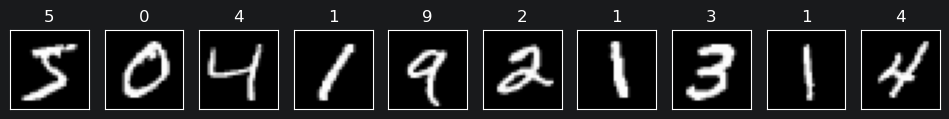

In [5]:
# 取前 10 个样本，图像和标签分开收集
X, y = [], []
for i in range(10):
    X.append(mnist_train[i][0])  # Tensor (1,28,28)
    y.append(mnist_train[i][1])  # 数字标签
show_mnist(X, get_mnist_labels(y))

In [6]:
batch_size = 256                               # 每批 256 个样本
num_workers = 0                                 # macOS 多进程设为 0 最稳定

# train_iter: 训练时 shuffle=True 打乱顺序，防止模型记住样本排列
# test_iter:  测试时 shuffle=False，评估结果可复现
train_iter = torch.utils.data.DataLoader(
    mnist_train, batch_size=batch_size,
    shuffle=True, num_workers=num_workers
)
test_iter = torch.utils.data.DataLoader(
    mnist_test, batch_size=batch_size,
    shuffle=False, num_workers=num_workers
)

# 测一下遍历全部训练数据需要多长时间
start = time.time() # 返回当前 Unix 时间戳（1970-01-01 以来的秒数，浮点数）
for X, y in train_iter:
    continue  # 只遍历不计算
print('读取一个 epoch 耗时: %.2f 秒' % (time.time() - start))


读取一个 epoch 耗时: 0.71 秒


In [7]:
num_inputs = 784   # 28×28 像素展平
num_outputs = 10   # 0~9 共 10 类

# W: 正态分布随机初始化，均值 0 标准差 0.01，形状 (784, 10)
#    每列对应一个类别的 784 个权重
# b: 10 维零向量，每类一个偏置
# requires_grad=True → PyTorch 会自动追踪这些参数的梯度
W = torch.tensor(np.random.normal(0, 0.01, (num_inputs, num_outputs)),
                 dtype=torch.float, requires_grad=True)
b = torch.zeros(num_outputs, dtype=torch.float, requires_grad=True)

print('W 形状:', W.shape, '  b 形状:', b.shape)  # (784,10) (10,)


W 形状: torch.Size([784, 10])   b 形状: torch.Size([10])


In [8]:
# dim=0: 沿第 0 维（行方向）操作 → 对同一列求和
# dim=1: 沿第 1 维（列方向）操作 → 对同一行求和
# keepdim=True:  保持原始维度数，结果仍是二维
# keepdim=False: 求和维度被消除，结果降一维
X = torch.tensor([[1, 2, 3], [4, 5, 6]])
print('原始:\\n', X)
print('dim=0, keepdim=True: ', X.sum(dim=0, keepdim=True))   # [[5,7,9]] —— 形状 (1,3)
print('dim=1, keepdim=True: ', X.sum(dim=1, keepdim=True))   # [[6],[15]] —— 形状 (2,1)
print('dim=1, keepdim=False:', X.sum(dim=1, keepdim=False))  # [6,15]   —— 形状 (2,)

原始:\n tensor([[1, 2, 3],
        [4, 5, 6]])
dim=0, keepdim=True:  tensor([[5, 7, 9]])
dim=1, keepdim=True:  tensor([[ 6],
        [15]])
dim=1, keepdim=False: tensor([ 6, 15])


In [9]:
def softmax(X):
    """
    输入 X: (batch_size, num_classes)，每行一个样本的得分向量 o
    步骤：
      1. exp: e^o_j，保证所有输出为正
      2. sum(dim=1): 每行求和得到归一化分母
      3. 除法: 广播机制使每行各自除以自己的分母
    输出: (batch_size, num_classes)，每行和为 1 的概率分布
    """
    X_exp = X.exp()
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

# 验证：2 个样本，5 个类别，每行概率和应为 1
X = torch.rand(2, 5)
X_prob = softmax(X)
print('原始得分:\\n', X)
print('Softmax 后概率:\\n', X_prob)
print('每行概率和:', X_prob.sum(dim=1))

原始得分:\n tensor([[0.9823, 0.2467, 0.1784, 0.8253, 0.9667],
        [0.4374, 0.4602, 0.8692, 0.7219, 0.9299]])
Softmax 后概率:\n tensor([[0.2655, 0.1272, 0.1188, 0.2270, 0.2614],
        [0.1532, 0.1567, 0.2359, 0.2036, 0.2507]])
每行概率和: tensor([1., 1.])


In [10]:
# 前向传播：每张图展平成 784 维 → 线性变换 Wx+b → softmax 转概率
# view(-1, num_inputs): -1 表示自动推导 batch_size，num_inputs=784
#   例如输入 (256, 1, 28, 28) → view 后 (256, 784)
# torch.mm(X_flat, W): (256, 784) × (784, 10) = (256, 10)，等价于 @
def net(X):
    return softmax(torch.mm(X.view((-1, num_inputs)), W) + b)

**模型与 batch_size 解耦**

`net` 定义为 `softmax(X.view(-1, 784) · W + b)`。数学上单个样本输出为 Wᵀx + b（10×1 列向量），代码为批量处理将样本横过来按行堆叠：

- X 形状 `(batch, 784)`，每行一个样本
- W 形状 `(784, 10)` 不变
- X · W = `(batch, 10)`，每行是该样本的 10 个得分

三个关键设计：
1. `view(-1, 784)` 中 `-1` 自动推导 batch_size，模型与每次塞多少个样本完全解耦
2. b `(10,)` 广播到 `(batch, 10)`，自动加在每行，无需手动扩展
3. W 和 b 学成后形状与 batch 无关——锁死的只有输入维度（784）和输出类别数（10）

本质：`(batch, 784) × (784, 10) = (batch, 10)` 将逐样本的列向量操作统一为批处理行堆叠，第一维始终自由。


In [18]:
# gather(dim, index): 沿 dim 维，按 index 取出对应位置的元素
#   此处 dim=1 表示在列上取值，index 是每行要取哪一列
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])  # 2 样本 × 3 类
y = torch.LongTensor([0, 2])         # 真实标签：样本 0 是第 0 类，样本 1 是第 2 类

# y.view(-1,1) 把 [0,2] 转成列向量 [[0],[2]]，gather 需要的索引格式
print('标签列向量:\\n', y.view(-1, 1))
print('gather 取出正确类别的概率:\\n', y_hat.gather(dim=1, index=y.view(-1, 1))) # index是一个张量，形状要和输入除 dim 维外一致
# 结果: [[0.1], [0.5]] —— 分别对应 y_hat[0][0] 和 y_hat[1][2]

标签列向量:\n tensor([[0],
        [2]])
gather 取出正确类别的概率:\n tensor([[0.1000],
        [0.5000]])


In [19]:
# 交叉熵损失: L = -log(ŷ_c)，c 为真实类别
#   gather 取出每个样本正确类别的预测概率，取负对数
def cross_entropy(y_hat, y):
    return -torch.log(y_hat.gather(1, y.view(-1, 1)))

# 准确率: 预测正确的样本数 / 总样本数
#   argmax(dim=1):  取每行最大值的索引 → 预测类别
#   (pred == y):    逐元素比较，返回布尔张量
#   .float().mean(): 1 的比例即为准确率
def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).float().mean().item()

print('准确率:', accuracy(y_hat, y))

准确率: 0.5


In [20]:
# 在整个数据集上评估模型准确率（不更新参数）
def evaluate_accuracy(data_iter, net):
    acc_sum, n = 0.0, 0
    for X, y in data_iter:
        acc_sum += (net(X).argmax(dim=1) == y).float().sum().item()  # 正确数
        n += len(y)                                                  # 样本总数，等价于 y.shape[0]
    return acc_sum / n

# 用随机初始化的参数预测，准确率应 ≈ 0.10（随机猜 10 类）
print('初始测试准确率:', evaluate_accuracy(test_iter, net))

初始测试准确率: 0.1085


In [25]:
num_epochs, lr = 8, 0.1   # 迭代 8 轮，学习率 0.1

def sgd(params, lr, batch_size):
    """小批量随机梯度下降：θ ← θ - (lr/batch_size) * ∂L/∂θ"""
    for param in params:
        # params[0] = W (784, 10)
        # params[1] = b (10,)
        param.data -= lr * param.grad / batch_size
        # param.grad：反向传播算出来的 ∂L/∂θ（这个参数让损失往哪变、变多少）
        # param.grad / batch_size：除以 batch 大小做平均（因为损失是 .sum() 而非 .mean()，不除的话 batch 越大梯度越大）
        # lr * ...：学习率控制步长——一次只挪一小步，不跳太远
        # param.data -= ...：往梯度反方向挪——梯度指向上坡，减号就是下坡


def train_ch3(net, train_iter, test_iter, loss, num_epochs, batch_size, params, lr):
    for epoch in range(num_epochs):
        train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
        for X, y in train_iter:
            y_hat = net(X)                   # 前向传播得预测概率
            l = loss(y_hat, y).sum()         # 计算这批样本的总损失
            
            # PyTorch 默认累加梯度——每次 backward() 不是覆盖 .grad，而是加到已有的 .grad 上
            if params[0].grad is not None:
                for param in params:
                    param.grad.data.zero_()
            
            l.backward()                     # 反向传播：自动计算所有参数梯度
            # backward() 干了两件事：
                # 计算：从 loss 出发，沿计算图反向走，用链式法则算出每个参数的梯度
                # 填入：把算出来的梯度累加到对应参数的 .grad 里
            sgd(params, lr, batch_size)      # 沿梯度方向更新参数
            
            train_l_sum += l.item()          # 累计损失
            train_acc_sum += (y_hat.argmax(dim=1) == y).float().sum().item()
            n += y.shape[0]
            # 防止训练集中数据个数不是 batch_size 的整数倍，导致最后一个 batch 数据少，直接做 mean 相加除以 batch 个数会导致加权问题
        
        test_acc = evaluate_accuracy(test_iter, net)
        print('epoch %d, loss %.4f, train acc %.3f, test acc %.3f'
              % (epoch + 1, train_l_sum / n, train_acc_sum / n, test_acc))

# 开始训练
train_ch3(net, train_iter, test_iter, cross_entropy,
          num_epochs, batch_size, [W, b], lr)

epoch 1, loss 0.3356, train acc 0.907, test acc 0.913
epoch 2, loss 0.3275, train acc 0.909, test acc 0.914
epoch 3, loss 0.3211, train acc 0.910, test acc 0.916
epoch 4, loss 0.3161, train acc 0.912, test acc 0.917
epoch 5, loss 0.3117, train acc 0.913, test acc 0.916
epoch 6, loss 0.3080, train acc 0.914, test acc 0.917
epoch 7, loss 0.3047, train acc 0.915, test acc 0.919
epoch 8, loss 0.3018, train acc 0.916, test acc 0.919


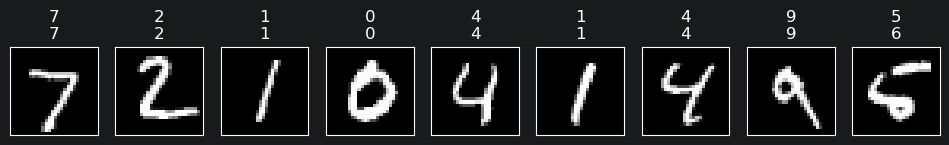

In [26]:
# 取一批测试数据，对比真实标签与模型预测
X, y = next(iter(test_iter))                    # 取第一个 batch
# iter(test_iter) 把 DataLoader 转成迭代器
true_labels = get_mnist_labels(y.numpy())        # 真实数字标签
pred_labels = get_mnist_labels(net(X).argmax(dim=1).numpy())  # 模型预测

# 每张图标题显示「真实\\n预测」
titles = [true + '\n' + pred for true, pred in zip(true_labels, pred_labels)]
show_mnist(X[0:9], titles[0:9])  # 展示前 9 张

In [27]:
# iter(): 将可迭代对象转为迭代器
# next(): 逐一取出下一个元素
a = [1, 2, 3, 4, 5]
a_iter = iter(a)
print(next(a_iter))  # 1
for item in a_iter:
    print(item)
# 全部取完后继续调用 next(a_iter) 会抛出 StopIteration

1
2
3
4
5


### 总结：Softmax 回归到底在干什么

整个过程可以理解为五个角色围绕一个目标展开协作：

- **X**：喂给模型的原始数据 —— 一批图，每张图拉成 784 个像素值。只负责看，不负责判断。
- **W 和 b**：模型身上唯二可调的东西。迭代的过程中不断修改二者，让模型学习什么样的像素组合对应什么数字"。
- **y**：你给模型的正确答案 —— 每张图的真实数字标签。模型看不到它（模型只看 X），但它会在算 loss 的时候指正，比如"你猜错了，这个其实是 5"。
- **ŷ**：模型看完 X，自己猜出来的概率分布 —— 一行里 10 个概率，对应"我有多确定它是 0、1、2 ... 9"。模型越不确定，概率越平摊；越确定，最大概率越接近 1。

**一句话总结迭代目标：**

通过反复修正 W 和 b，让模型对每个样本猜测的概率分布 ŷ 中，**正确类别 y 对应的那个概率值 ŷ_c 越来越接近 1**。换句话说——模型被训练后，给它一张 5 的图，它在第 5 列的输出概率应该碾压其它 9 列。

**准确率怎么看：**

把 ŷ 每行最大概率所在的列号（模型最终拍板的"我认为这是几"）和 y（实际上它是几）比对，一致的就算对，不一致的就算错。对的占总数的比例就是准确率。

